# 06 — Comparación SDCT/LDCT y diferencias de sinogramas

## Objetivo

Reproducir las cuatro comparaciones absolutas y relativas utilizadas en los resultados ampliados.

**Alcance:** Hito 1 actualizado.

## Datos utilizados

Par TCIA C095/1-250 de `config/default.json`. Las rutas DICOM se configuran en ese JSON; por defecto se usan data/sdct y data/ldct. Cada notebook se ejecuta de forma independiente.

## Procedimiento

Usar los cuatro sinogramas fijos. Comparar SDCT/LDCT con y sin ruido añadido, y cada entrada antes/después del ruido. En porcentaje usar siempre |sinograma SDCT sin ruido añadido| como denominador y excluir señal ≤1 % del máximo.

**Procedencia:** sdct_ldct_sinograma_gaussiano.ipynb, celdas 24 y 31; Resultados_TCIA.pptx, diapositivas 3–11; detalles en `../REFACTOR_MAP.md`.

## Parámetros

In [1]:
from pathlib import Path
import os
import sys
sys.dont_write_bytecode = True
start = Path.cwd().resolve()
root = next((p for p in (start, *start.parents) if (p / 'src/config.py').is_file() and (p / 'config/default.json').is_file()), None)
if root is None and (start / 'hito1-mini-tesis/src').is_dir():
    root = start / 'hito1-mini-tesis'
if root is None:
    raise RuntimeError('Abre Jupyter desde la raíz del repositorio o su carpeta notebooks.')
sys.path.insert(0, str(root))
os.environ['MPLCONFIGDIR'] = str(root / 'outputs/.matplotlib')
import numpy as np
from src.config import load_config, output_path
from src.experiments import prepare_pair
from src.io import save_table
from src.visualization import show_table, finish_figure
config = load_config()
show_table([{key: config[key] for key in ('num_angles', 'sigma_gaussian', 'seed', 'filter_name', 'visual_amplification')}])

num_angles,sigma_gaussian,seed,filter_name,visual_amplification
512,1,42,ramp,5


## Resultados

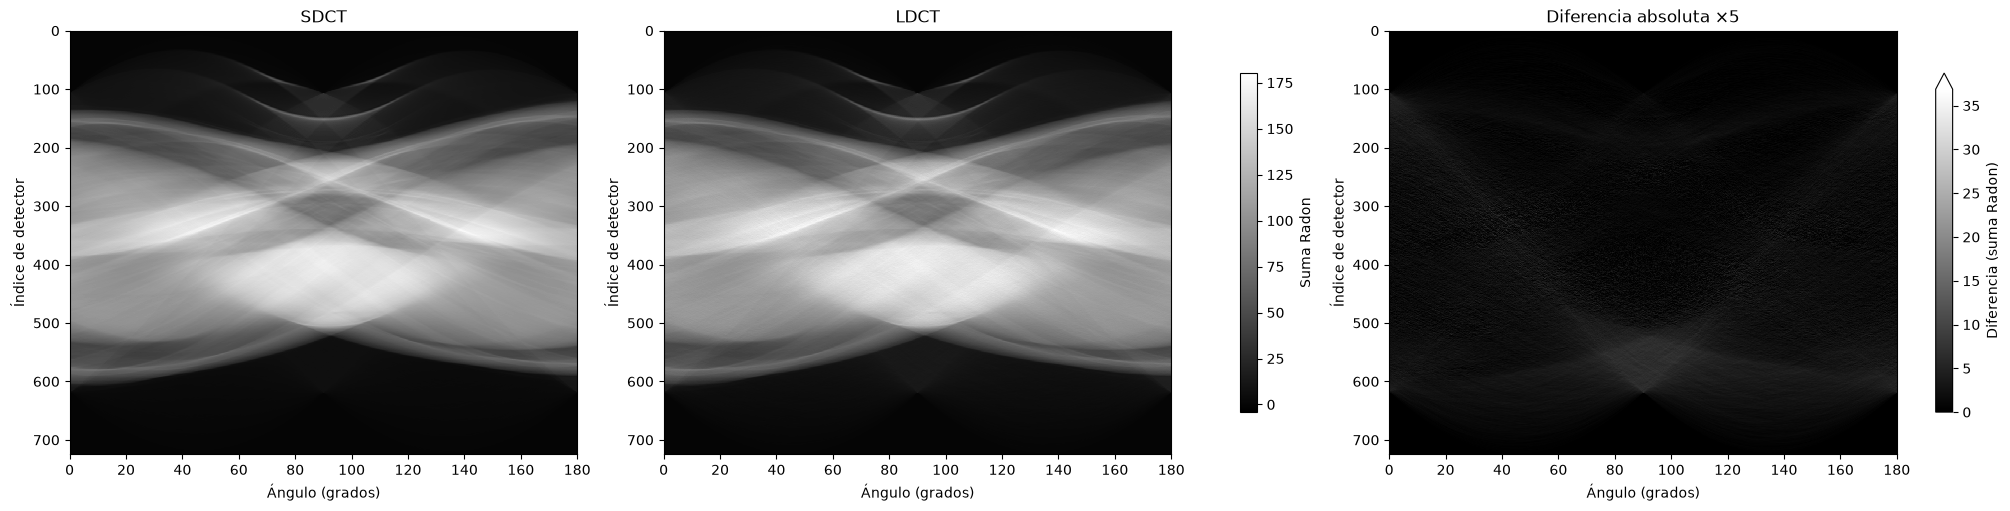

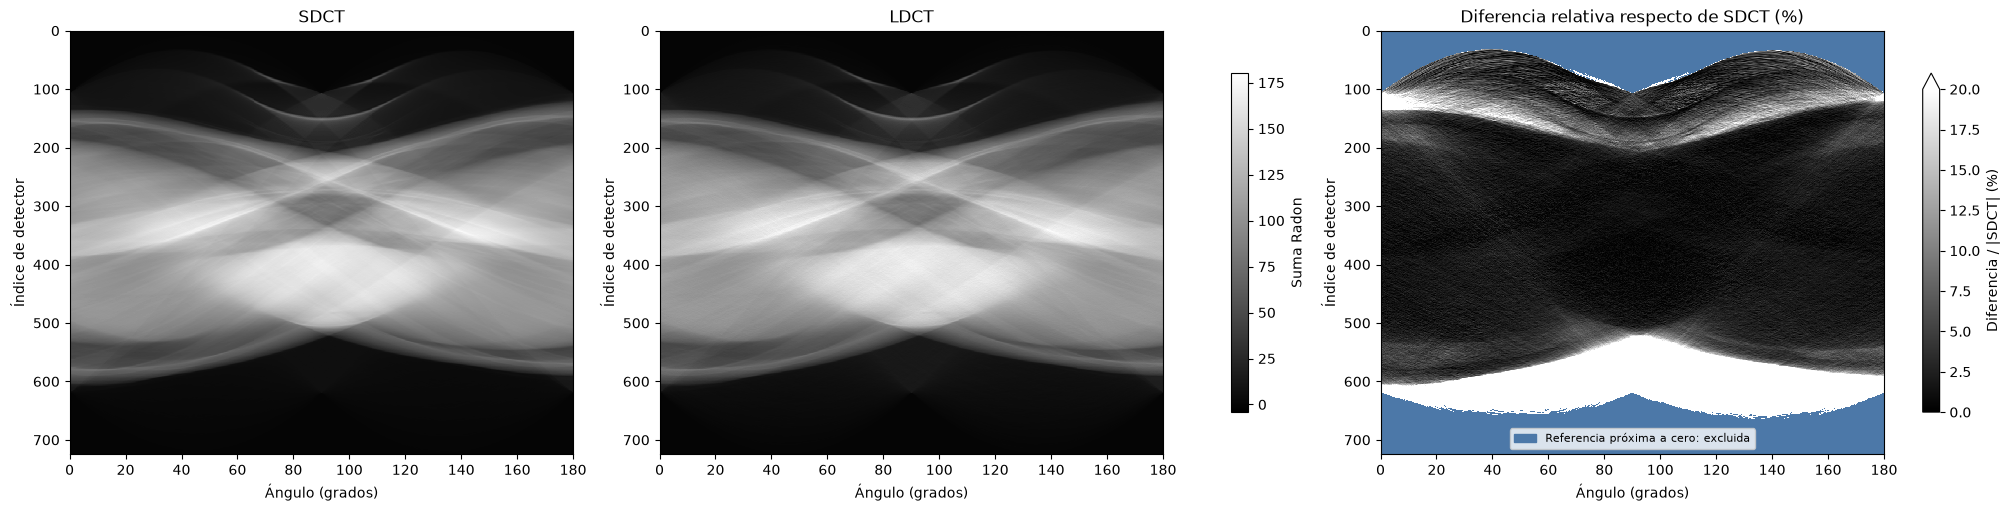

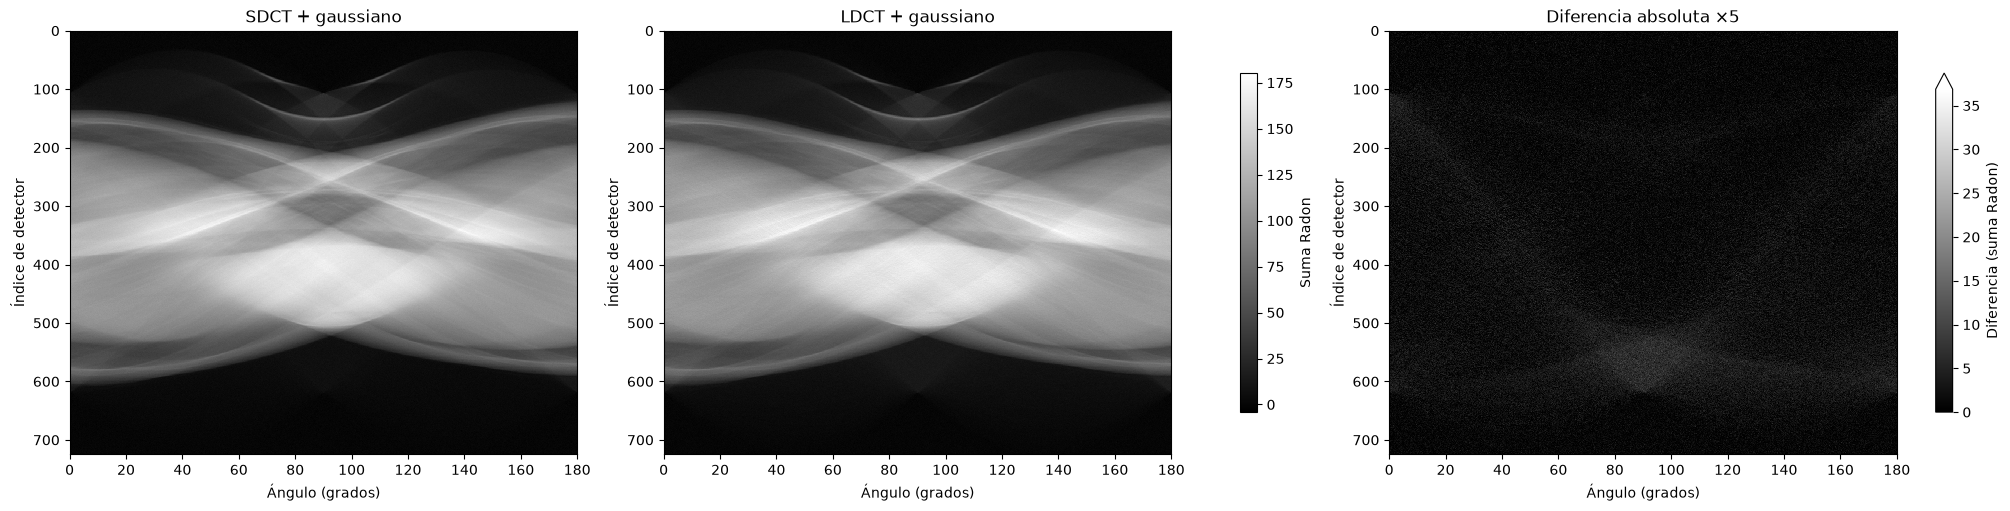

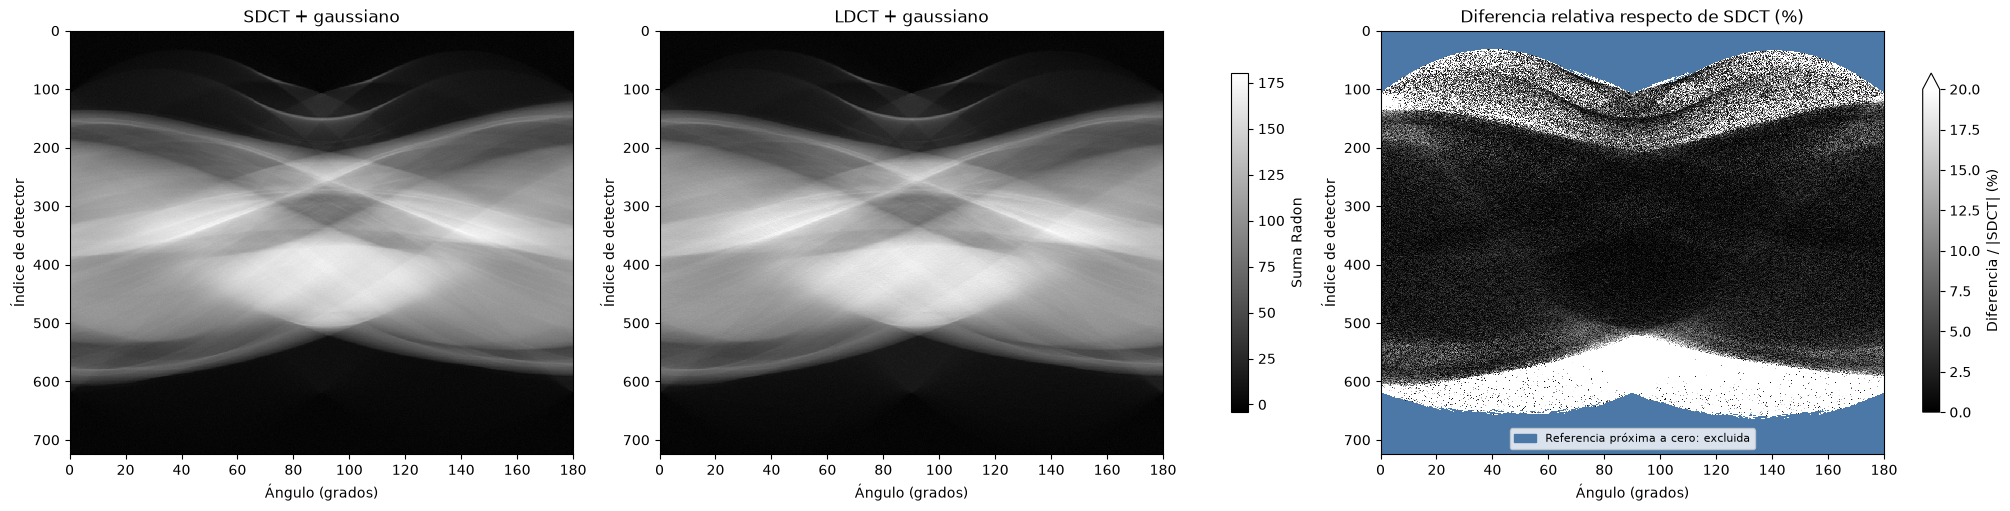

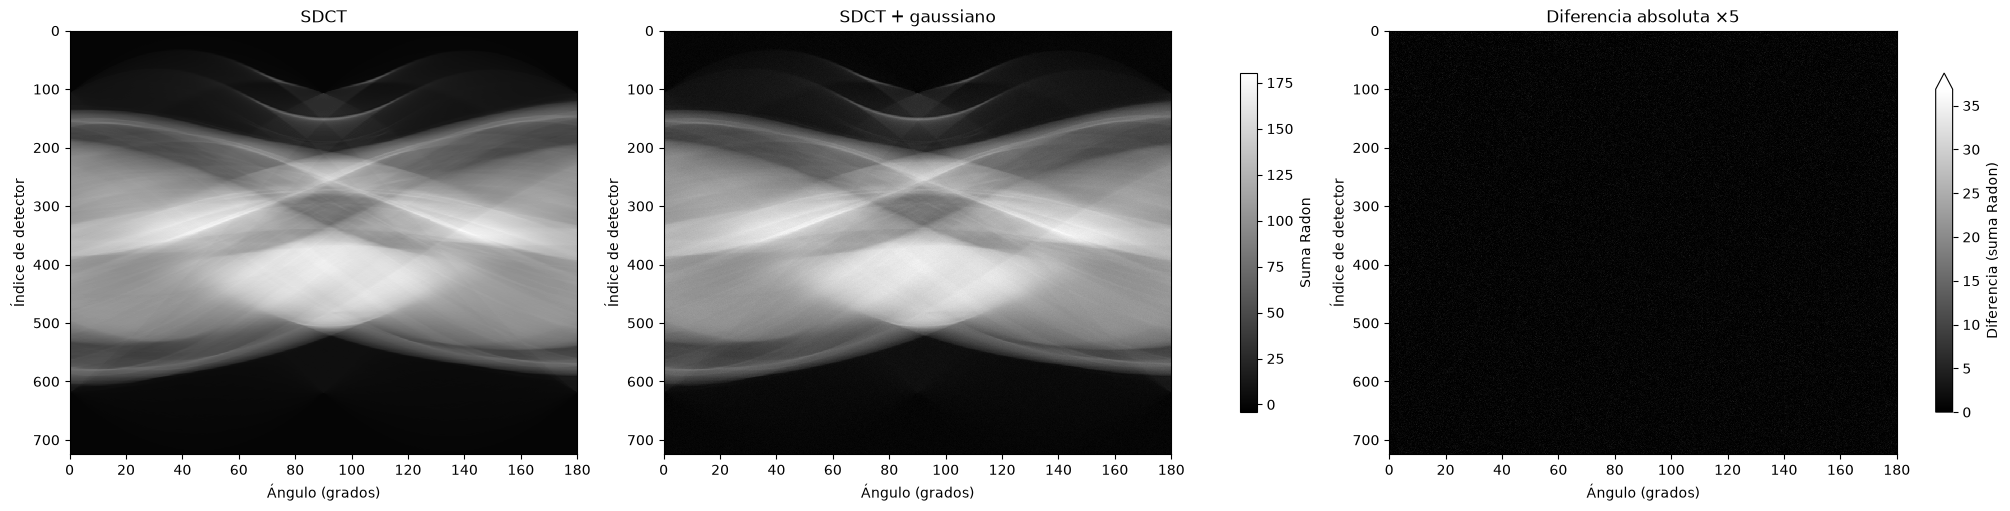

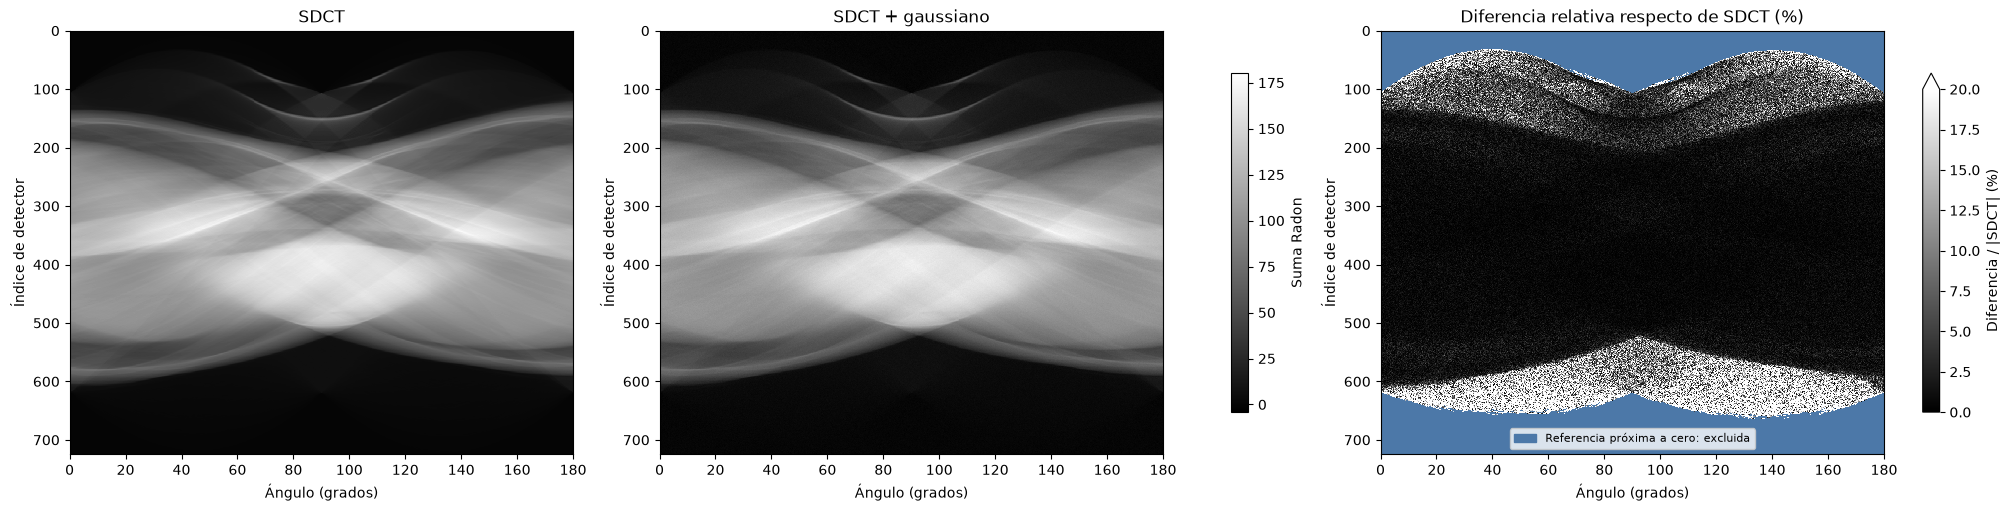

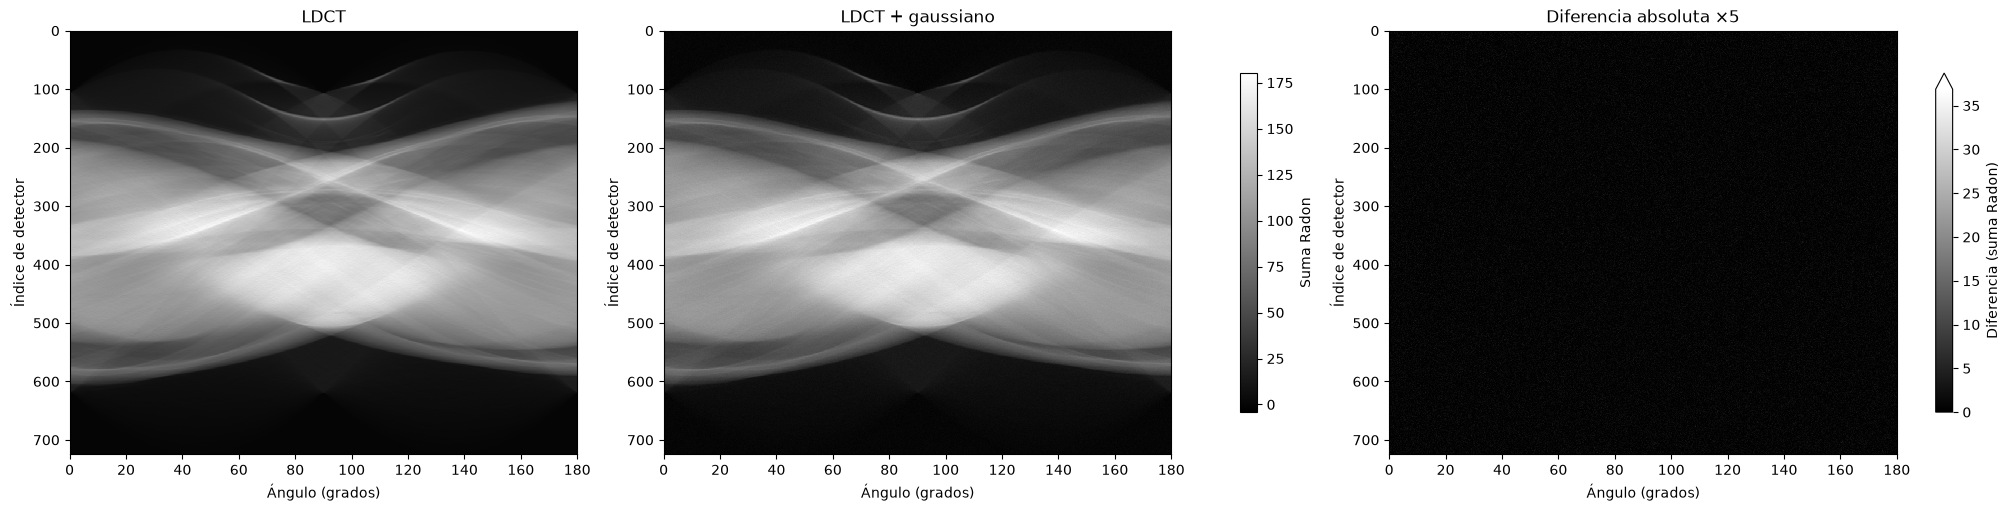

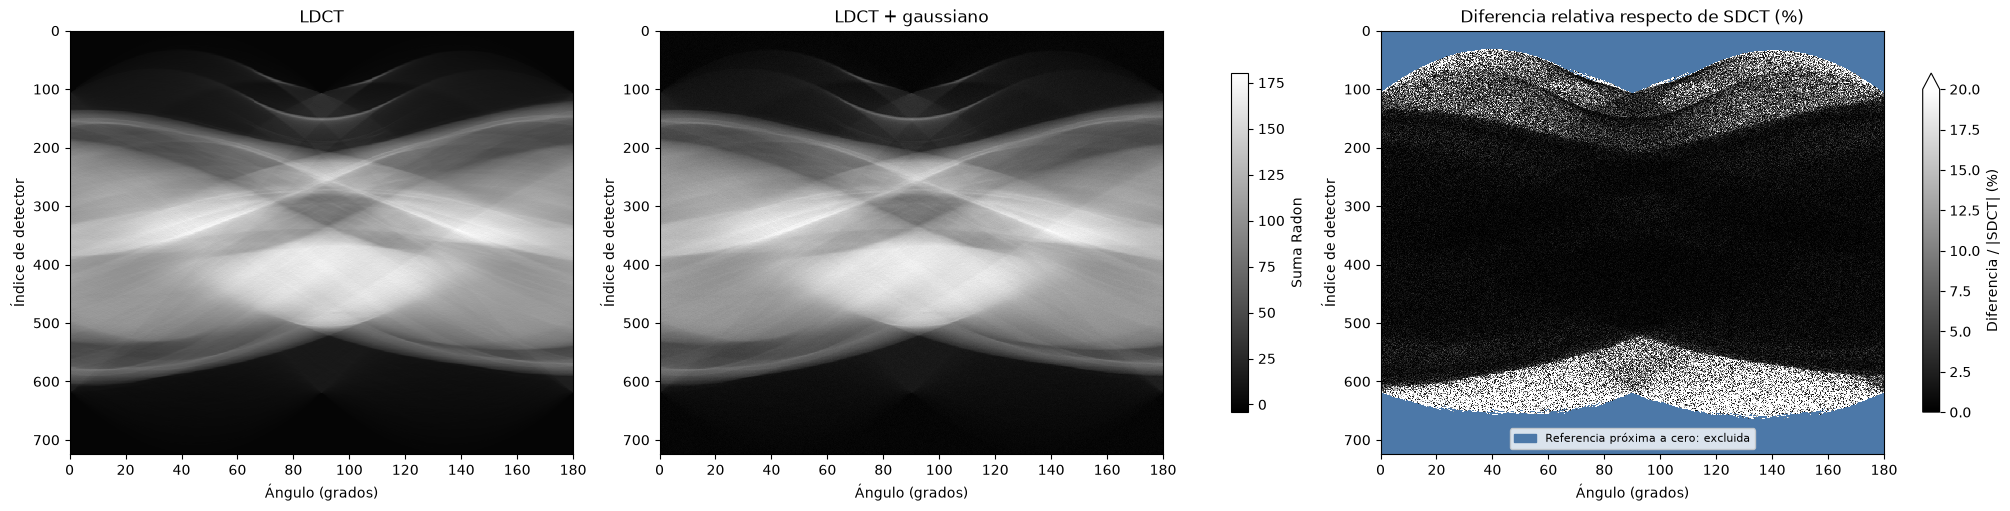

In [2]:
from src.experiments import gaussian_conditions, sinogram_comparisons
from src.metrics import error_metrics, relative_sinogram_difference
from src.visualization import plot_sinogram_comparison
pair = prepare_pair(config)
conditions = gaussian_conditions(pair, config)
limits = (min(float(c['sinogram'].min()) for c in conditions), max(float(c['sinogram'].max()) for c in conditions))
rows, relative_rows = [], []
for name, a, b, label_a, label_b in sinogram_comparisons(conditions):
    rows.append(dict(comparison=name, **error_metrics(a, b)))
    fig = plot_sinogram_comparison(a, b, (label_a, label_b), limits, amplification=config['visual_amplification'])
    finish_figure(fig, output_path('figures', '06_absolute_' + name + '.png'))
    relative, stats = relative_sinogram_difference(a, b, conditions[0]['sinogram'], config['relative_threshold_fraction'])
    stats['sobre_limite_visual_pct'] = float(100 * np.mean(relative[np.isfinite(relative)] > config['relative_display_max_pct']))
    relative_rows.append(dict(comparison=name, **stats))
    fig = plot_sinogram_comparison(a, b, (label_a, label_b), limits,
                                  relative=relative, relative_max=config['relative_display_max_pct'])
    finish_figure(fig, output_path('figures', '06_relative_' + name + '.png'))

In [3]:
show_table(rows)
show_table(relative_rows)
save_table(rows, output_path('tables', '06_sinograms.csv'))
save_table(relative_rows, output_path('tables', '06_relative_sinograms.csv'))

comparison,MAE,RMSE,MAX
sdct_ldct_sin_ruido,1.63864,2.1144,8.96479
sdct_ldct_con_ruido,2.01802,2.54377,11.8845
sdct_sin_vs_con_ruido,0.796,0.997982,4.7368
ldct_sin_vs_con_ruido,0.799248,1.00063,4.90333


comparison,media_pct,mediana_pct,maximo_pct,evaluado_pct,sobre_limite_visual_pct
sdct_ldct_sin_ruido,14.8402,2.4336,151.533,80.6468,13.3261
sdct_ldct_con_ruido,16.1002,2.78976,364.327,80.6468,15.7178
sdct_sin_vs_con_ruido,4.99579,1.03874,221.562,80.6468,6.81986
ldct_sin_vs_con_ruido,5.02544,1.04474,178.555,80.6468,6.84558


## Observaciones

Las métricas absolutas están en suma Radon, sin ×5. El porcentaje depende del denominador y del umbral. Azul significa excluido, negro diferencia cero. La resta antes/después del ruido aísla la gaussiana añadida; SDCT−LDCT también contiene diferencias de adquisición y anatomía. No demuestra un modelo Poisson.